In [1]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import xarray as xr
import zarr
import regionmask

In [2]:
dir = '/glade/derecho/scratch/soren/src/icar/sams_stat_files/'
agreement_dir = dir + 'agreement/'


# to create 
- [ ] pr
- [ ] tasmin
- [ ] tasmax

In [3]:
def infer_model_name(path):
    # ICAR_CMIP5_signal_pr.nc -> ICAR
    return path.name.split("_CMIP5_signal_")[0]

def add_all_gcms(ds):
    # Avoid duplicating AllGCMs if the function is called again.
    if "AllGCMs" in ds["gcm"].values:
        ds = ds.drop_sel(gcm="AllGCMs")

    # Average each output variable across the existing GCMs.
    all_gcms = (
        ds.mean("gcm", skipna=True, keep_attrs=True)
        .expand_dims(gcm=["AllGCMs"])
    )

    return xr.concat([ds, all_gcms], dim="gcm")
def make_conus_mask(obj):
    """
    Return a 2-D Boolean DataArray with dimensions (lat, lon).

    True  = grid-cell center is inside the contiguous United States
    False = outside CONUS
    """
    states = (
        regionmask.defined_regions
        .natural_earth_v5_0_0
        .us_states_50
    )

    # One Boolean layer for each state.
    state_masks = states.mask_3D(
        obj["lon"],
        obj["lat"],
        wrap_lon=180,
        drop=False,
    )

    # Retain the lower 48 states. District of Columbia is retained
    # if it is represented separately in the state polygons.
    excluded = state_masks["names"].isin(
        ["Alaska", "Hawaii"]
    )

    conus_mask = (
        state_masks
        .where(~excluded, drop=True)
        .any("region")
        .rename("conus_mask")
    )

    conus_mask.attrs.update(
        {
            "long_name": "contiguous United States mask",
            "description": (
                "True where the grid-cell center lies within one of the "
                "contiguous United States; Alaska and Hawaii excluded."
            ),
        }
    )

    return conus_mask

def find_signal_var(ds):
    """
    Guess the main data variable in the file.
    Adjust this if your variable has a known name like 'signal', 'pr', etc.
    """
    data_vars = list(ds.data_vars)
    if len(data_vars) == 1:
        return data_vars[0]

    # Prefer common names if present
    # ['mean_tasmax', 'mean_jja_tasmax', 'q95_tasmax']
    # 
    for name in ["mean_jja_pr", "mean_jja_prcp", "mean_jja_tasmax"]:
        if name in ds.data_vars:
            return name

    raise ValueError(f"Could not identify signal variable. Found: {data_vars}")


def open_signal_ensemble(dir, pattern):
    """
    Open files from multiple downscaling models and stack them into:

        downscaling_model, gcm, lat, lon
    """
    files = sorted(Path(dir).glob(pattern))

    if not files:
        raise FileNotFoundError(f"No files found matching {pattern}")

    arrays = []
    model_names = []

    for f in files:
        ds = xr.open_dataset(f)
        print(f"looking at {f}")
        print(list(ds.variables))

        
        if 'gcm' not in list(ds.variables):
            sys.exit('gcm not in file')
        varname = find_signal_var(ds)
        print(ds.gcm.data)
        keep = ["CanESM2", "NorESM1-M", "MIROC5", "GFDL-CM3", "MRI-CGCM3",]
        available = [gcm for gcm in keep if gcm in ds["gcm"].values]
        ds = ds.sel(gcm=available)
        
        da = ds[varname]

        model_name = infer_model_name(f)
        da = da.expand_dims(downscaling_model=[model_name])

        arrays.append(da)
        model_names.append(model_name)

    signal = xr.concat(arrays, dim="downscaling_model", coords='minimal')
    # Create the lower-48 mask and set everything outside it to NaN.
    conus_mask = make_conus_mask(signal)
    signal = signal.where(conus_mask)

    return signal, conus_mask
    #return signal


# The signal-to-noise ratio calculated as divided by the standard deviation across the estimated signals from all downscaled datasets.
def compute_snr_and_agreement(
    signal,
    conus_mask,
    min_models=2,):    
    """
    Parameters
    ----------
    signal : xr.DataArray
        Expected dimensions:
        downscaling_model, gcm, lat, lon

    min_models : int
        Minimum number of valid downscaling models required to calculate
        agreement and SNR.

    Returns
    -------
    snr_ds : xr.Dataset
    agreement_ds : xr.Dataset
    """

    # Ensure all source values outside CONUS are NaN.
    signal = signal.where(conus_mask)

    # Number of valid downscaling datasets at each location
    valid = signal.notnull()
    n_models = valid.sum("downscaling_model")

    # Mean and standard deviation over available downscaling datasets
    signal_mean = signal.mean("downscaling_model", skipna=True)
    signal_std = signal.std("downscaling_model", skipna=True)

    # Avoid division by zero and avoid reporting SNR with too few models
    snr = xr.where(
        (signal_std > 0.0) & (n_models >= min_models),
        signal_mean / signal_std,
        np.nan,
    )

    snr_abs = np.abs(snr)

    snr_ds = xr.Dataset(
        {
            "signal_mean": signal_mean,
            "signal_std": signal_std,
            "snr": snr,
            "snr_abs": snr_abs,
            "n_downscaling_models": n_models.astype("int16"),
        }
    )

    snr_ds["snr"].attrs.update(
        {
            "long_name": "signal-to-noise ratio",
            "description": (
                "Mean climate-change signal across available downscaling "
                "models divided by the standard deviation across those models."
            ),
        }
    )

    # Count the sign of each valid signal
    n_positive = ((signal > 0.0) & valid).sum("downscaling_model")
    n_negative = ((signal < 0.0) & valid).sum("downscaling_model")
    n_zero = ((signal == 0.0) & valid).sum("downscaling_model")

    sufficient_models = n_models >= min_models

    # Agreement means every available signal is positive,
    # or every available signal is negative.
    agree_positive = (
        sufficient_models
        & (n_positive == n_models)
    )

    agree_negative = (
        sufficient_models
        & (n_negative == n_models)
    )

    agreement = agree_positive | agree_negative

    # Disagreement includes mixed signs or an exact zero.
    disagreement = sufficient_models & ~agreement

    #  1 = all positive
    # -1 = all negative
    #  0 = disagreement
    # -9 = insufficient data
    direction = xr.where(
        ~sufficient_models,
        -9,
        xr.where(
            agree_positive,
            1,
            xr.where(agree_negative, -1, 0),
        ),
    ).astype("int8")

    # Integer version convenient for logical testing:
    # 1 = agreement, 0 = disagreement, -1 = insufficient data
    agreement_code = xr.where(
        ~sufficient_models,
        -1,
        agreement.astype("int8"),
    ).astype("int8")

    # This is the variable to use for hatching:
    # 1 where hatching should appear; 0 elsewhere.
    disagreement_mask = disagreement.astype("int8")

    # A floating-point version can be useful for plotting.
    # Non-hatched areas are NaN and therefore transparent.
    hatch_mask = xr.where(
        disagreement,
        1.0,
        np.nan,
    ).astype("float32")

    agreement_ds = xr.Dataset(
        {
            "agreement": agreement_code,
            "disagreement": disagreement_mask,
            "hatch_mask": hatch_mask,
            "direction": direction,
            "agree_positive": agree_positive.astype("int8"),
            "agree_negative": agree_negative.astype("int8"),
            "n_positive": n_positive.astype("int16"),
            "n_negative": n_negative.astype("int16"),
            "n_zero": n_zero.astype("int16"),
            "n_downscaling_models": n_models.astype("int16"),
        }
    )

    agreement_ds["agreement"].attrs.update(
        {
            "long_name": "downscaled-dataset sign agreement",
            "flag_values": np.array([-1, 0, 1], dtype="int8"),
            "flag_meanings": (
                "insufficient_data disagreement agreement"
            ),
        }
    )

    agreement_ds["disagreement"].attrs.update(
        {
            "long_name": "hatching mask for signal disagreement",
            "description": (
                "1 where available downscaling datasets do not all agree "
                "on whether the climate-change signal is positive or negative; "
                "0 elsewhere."
            ),
            "flag_values": np.array([0, 1], dtype="int8"),
            "flag_meanings": "not_hatched hatched",
        }
    )

    agreement_ds["hatch_mask"].attrs.update(
        {
            "long_name": "floating-point hatching mask",
            "description": (
                "1 where downscaling datasets disagree on signal direction; "
                "NaN elsewhere."
            ),
        }
    )

    agreement_ds["direction"].attrs.update(
        {
            "long_name": "direction of agreed signal",
            "flag_values": np.array([-9, -1, 0, 1], dtype="int8"),
            "flag_meanings": (
                "insufficient_data all_negative disagreement all_positive"
            ),
        }
    )

    #return snr_ds, agreement_ds

    # Set every output variable outside CONUS to NaN.
    #
    # This will convert integer flag/count variables to floating point
    # because integer arrays cannot represent NaN.
    snr_ds = snr_ds.where(conus_mask)
    agreement_ds = agreement_ds.where(conus_mask)

    # Add an AllGCMs entry containing the mean of the calculated outputs.
    snr_ds = add_all_gcms(snr_ds)
    agreement_ds = add_all_gcms(agreement_ds)
    
    # Include a reusable numerical mask in both files:
    # 1 inside CONUS and NaN outside.
    conus_output_mask = xr.where(
        conus_mask,
        1.0,
        np.nan,
    ).astype("float32")

    snr_ds["conus_mask"] = conus_output_mask
    agreement_ds["conus_mask"] = conus_output_mask

    snr_ds["conus_mask"].attrs.update(
        {
            "long_name": "contiguous United States mask",
            "description": "1 inside CONUS; NaN outside CONUS.",
        }
    )

    agreement_ds["conus_mask"].attrs.update(
        snr_ds["conus_mask"].attrs
    )

    return snr_ds, agreement_ds

In [4]:
signal_pr, conus_mask = open_signal_ensemble(dir, "*CMIP5_signal_pr.nc")

snr_pr, agreement_pr = compute_snr_and_agreement(
    signal_pr,
    conus_mask,
    min_models=2,
)

snr_pr.to_netcdf(agreement_dir+"signal_pr_snr.nc")
agreement_pr.to_netcdf(agreement_dir+"signal_pr_agreement.nc")
#["CanESM2", "NorESM1-M", "MIROC5",          "GFDL-CM3", "MRI-CGCM3",]

looking at /glade/derecho/scratch/soren/src/icar/sams_stat_files/BCCA_CMIP5_signal_pr.nc
['mean_pr', 'mean_jja_pr', 'sum_pr', 'q95_pr', 'std_pr', '2yr_pr', 'lat', 'lon', 'gcm']
['CanESM2' 'CNRM-CM5' 'IPSL-CM5A-MR' 'MIROC5' 'MRI-CGCM3' 'NorESM1-M']
looking at /glade/derecho/scratch/soren/src/icar/sams_stat_files/BCSD_CMIP5_signal_pr.nc
['mean_pr', 'mean_jja_pr', 'sum_pr', 'q95_pr', 'std_pr', '2yr_pr', '5yr_pr', 'lat', 'lon', 'gcm']
['CanESM2' 'CNRM-CM5' 'GFDL-CM3' 'IPSL-CM5A-MR' 'MIROC5' 'MRI-CGCM3'
 'NorESM1-M']
looking at /glade/derecho/scratch/soren/src/icar/sams_stat_files/GARD_CMIP5_signal_pr.nc
['mean_pr', 'mean_jja_pr', 'sum_pr', 'q95_pr', 'std_pr', '2yr_pr', '5yr_pr', 'lat', 'lon', 'gcm']
['CanESM2' 'GFDL-CM3' 'MIROC5' 'MRI-CGCM3' 'NorESM1-M']
looking at /glade/derecho/scratch/soren/src/icar/sams_stat_files/ICAR_CMIP5_signal_pr.nc
['mean_pr', 'mean_jja_pr', 'sum_pr', 'q95_pr', 'std_pr', '2yr_pr', '5yr_pr', 'lat', 'lon', 'gcm']
['CanESM2' 'GFDL-CM3' 'MIROC5' 'MRI-CGCM3' 'NorESM1-

/glade/derecho/scratch/soren/tmp/ipykernel_51718/2590880774.py:118: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'lat' ('lat',) The recommendation is to set join explicitly for this case.
  signal = xr.concat(arrays, dim="downscaling_model", coords='minimal')
/glade/derecho/scratch/soren/tmp/ipykernel_51718/2590880774.py:118: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'lon' ('lon',) The recommendation is to set join explicitly for this case.
  signal = xr.concat(arrays, dim="downscaling_model", coords='minima

In [5]:
signal_tasmax, conus_mask = open_signal_ensemble(dir, "*CMIP5_signal_tasmax.nc")

snr_tasmax, agreement_tasmax = compute_snr_and_agreement(
    signal_tasmax,
    conus_mask,
    min_models=2,
)

snr_tasmax.to_netcdf(agreement_dir+"signal_tasmax_snr.nc")
agreement_tasmax.to_netcdf(agreement_dir+"signal_tasmax_agreement.nc")

looking at /glade/derecho/scratch/soren/src/icar/sams_stat_files/BCCA_CMIP5_signal_tasmax.nc
['mean_tasmax', 'mean_jja_tasmax', 'q95_tasmax', 'lat', 'lon', 'gcm']
['CanESM2' 'CNRM-CM5' 'IPSL-CM5A-MR' 'MIROC5' 'MRI-CGCM3' 'NorESM1-M']
looking at /glade/derecho/scratch/soren/src/icar/sams_stat_files/BCSD_CMIP5_signal_tasmax.nc
['mean_tasmax', 'mean_jja_tasmax', 'q95_tasmax', 'lat', 'lon', 'gcm']
['CanESM2' 'CNRM-CM5' 'GFDL-CM3' 'IPSL-CM5A-MR' 'MIROC5' 'MRI-CGCM3'
 'NorESM1-M']
looking at /glade/derecho/scratch/soren/src/icar/sams_stat_files/GARD_CMIP5_signal_tasmax.nc
['mean_tasmax', 'mean_jja_tasmax', 'q95_tasmax', 'lat', 'lon', 'gcm']
['CanESM2' 'GFDL-CM3' 'MIROC5' 'MRI-CGCM3' 'NorESM1-M']
looking at /glade/derecho/scratch/soren/src/icar/sams_stat_files/ICAR_CMIP5_signal_tasmax.nc
['mean_tasmax', 'mean_jja_tasmax', 'q95_tasmax', 'lat', 'lon', 'gcm']
['CanESM2' 'GFDL-CM3' 'MIROC5' 'MRI-CGCM3' 'NorESM1-M']
looking at /glade/derecho/scratch/soren/src/icar/sams_stat_files/LOCA_CMIP5_signal

/glade/derecho/scratch/soren/tmp/ipykernel_51718/2590880774.py:118: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'lat' ('lat',) The recommendation is to set join explicitly for this case.
  signal = xr.concat(arrays, dim="downscaling_model", coords='minimal')
/glade/derecho/scratch/soren/tmp/ipykernel_51718/2590880774.py:118: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'lon' ('lon',) The recommendation is to set join explicitly for this case.
  signal = xr.concat(arrays, dim="downscaling_model", coords='minima

In [17]:
# looks like no tasmin plots in paper
#var = 'tasmin'
#signal_pr = open_signal_ensemble(dir, f"*_signal_{var}.nc")

#snr_pr, agreement_pr = compute_snr_and_agreement(signal_pr)

#snr_pr.to_netcdf(agreement_dir+f"signal_{var}_snr.nc")
#agreement_pr.to_netcdf(agreement_dir+f"signal_{var}_agreement.nc")

In [12]:
ds

<xarray.Dataset> Size: 49MB
Dimensions:               (gcm: 13, lat: 224, lon: 464, member_id: 1)
Coordinates:
  * gcm                   (gcm) <U12 624B 'ACCESS-CM2' ... 'NorESM2-MM'
  * lat                   (lat) float32 896B 25.06 25.19 25.31 ... 52.81 52.94
  * lon                   (lon) float32 2kB -124.9 -124.8 ... -67.19 -67.06
    quantile              float64 8B ...
Dimensions without coordinates: member_id
Data variables:
    signal_mean           (gcm, lat, lon, member_id) float64 11MB ...
    signal_std            (gcm, lat, lon, member_id) float64 11MB ...
    snr                   (gcm, lat, lon, member_id) float64 11MB ...
    snr_abs               (gcm, lat, lon, member_id) float64 11MB ...
    n_downscaling_models  (gcm, lat, lon, member_id) float32 5MB ...
    conus_mask            (lat, lon) float32 416kB ...

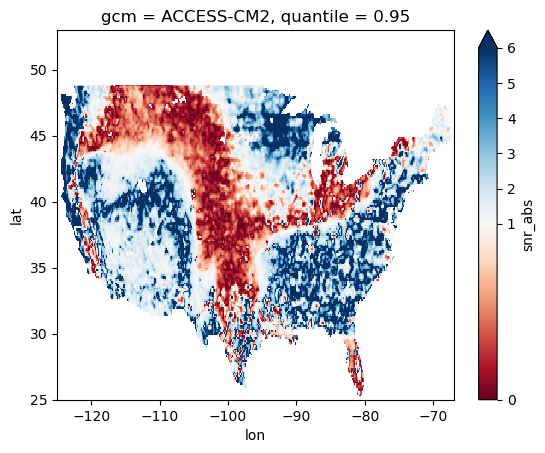

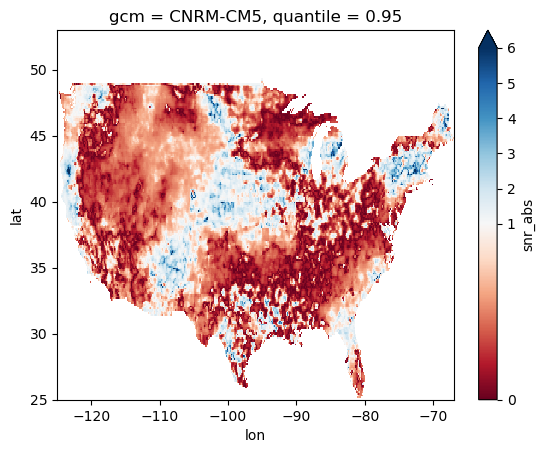

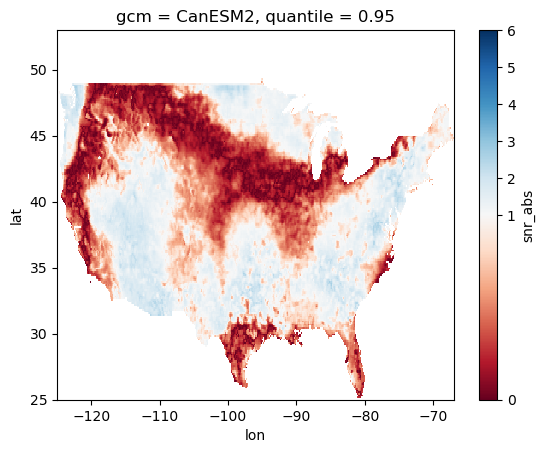

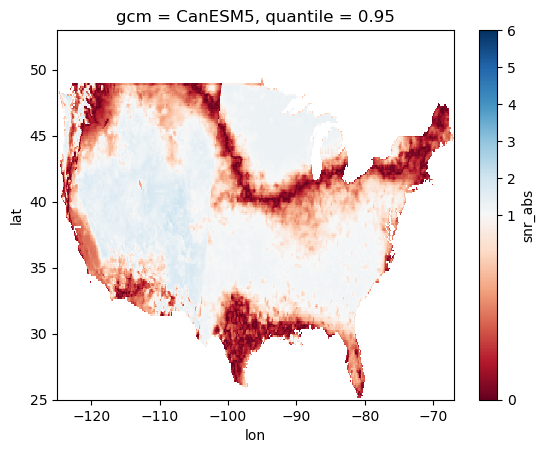

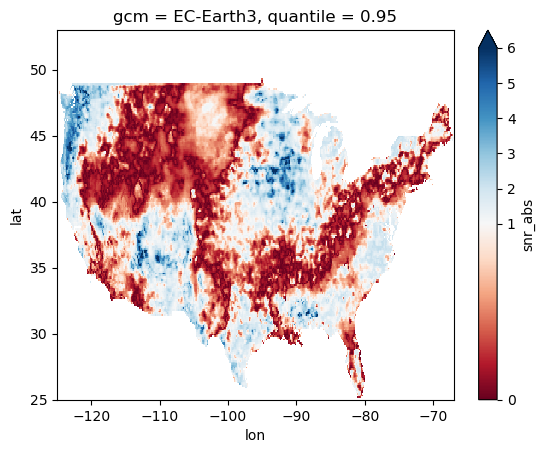

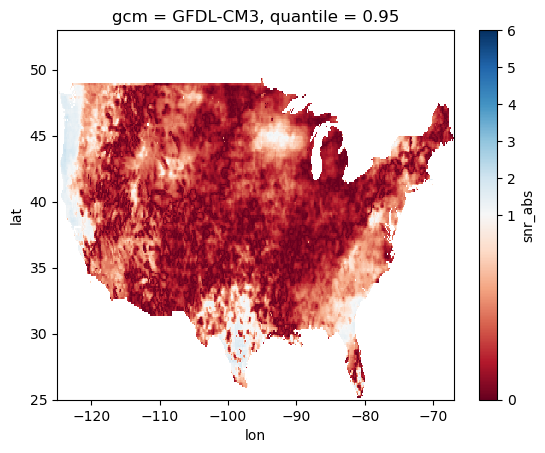

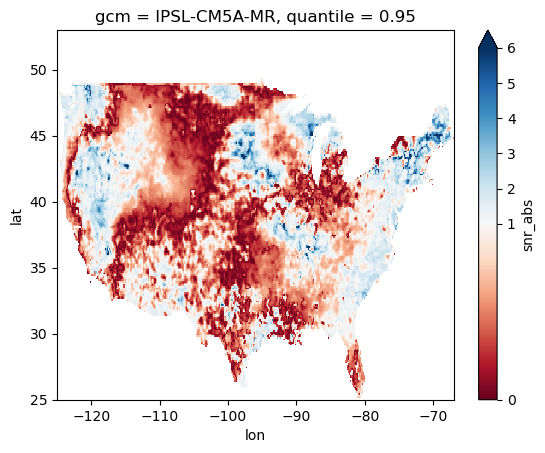

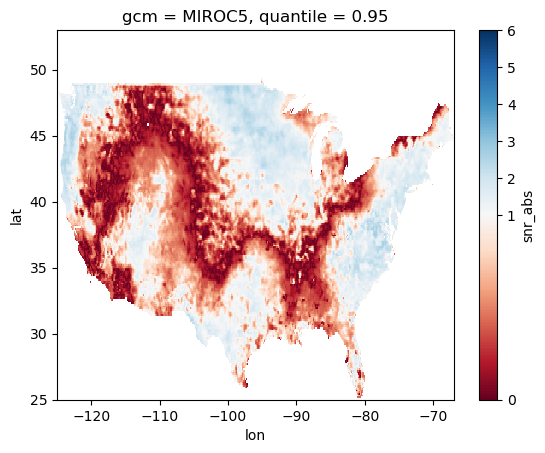

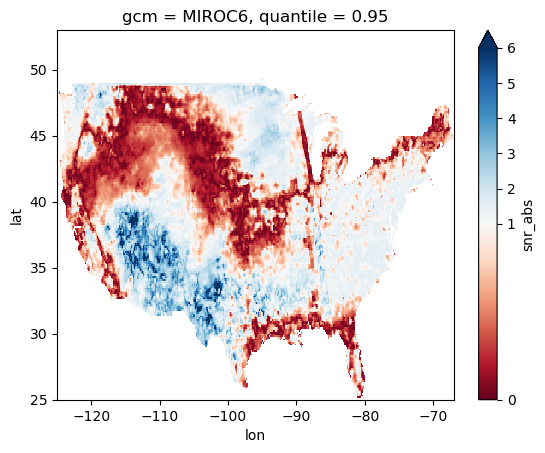

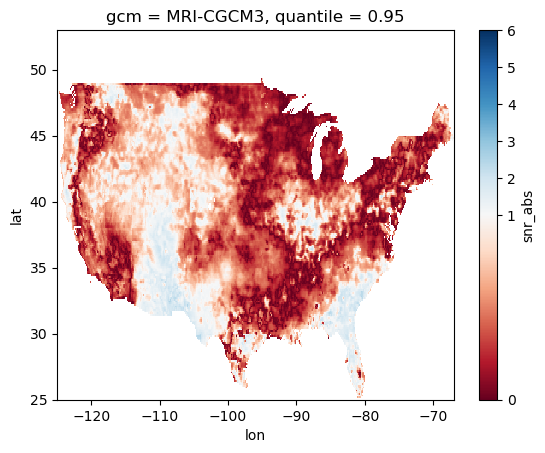

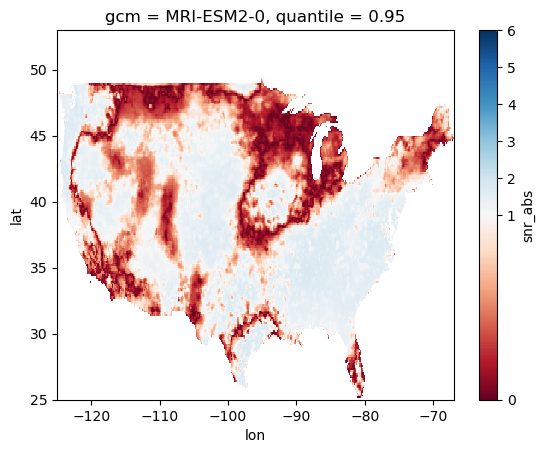

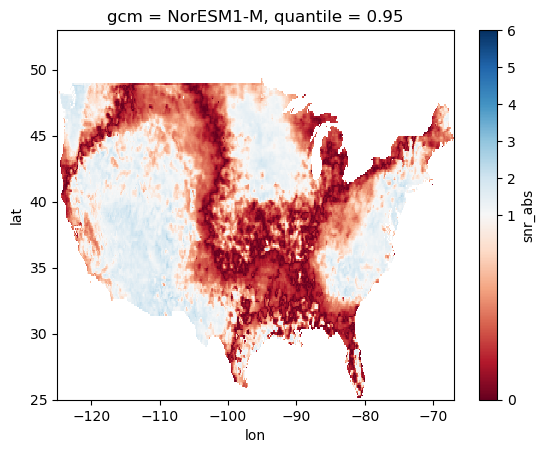

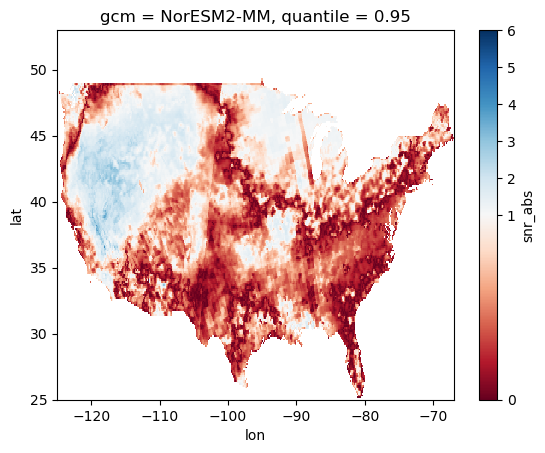

In [13]:
ds = xr.open_dataset(agreement_dir+"signal_pr_snr.nc")
ds
var = 'snr_abs'
norm = mcolors.TwoSlopeNorm(
    vmin=0.0,
    vcenter=1.0,
    vmax=6.0,
)
for gcm in list(ds.gcm):
    ds.sel(gcm=gcm)[var].plot(vmin=0.0, vmax=6.0, norm=norm, cmap="RdBu"); plt.show()

In [8]:
ds

<xarray.Dataset> Size: 54MB
Dimensions:               (gcm: 13, lat: 224, lon: 464, member_id: 1)
Coordinates:
  * gcm                   (gcm) <U12 624B 'ACCESS-CM2' ... 'NorESM2-MM'
  * lat                   (lat) float32 896B 25.06 25.19 25.31 ... 52.81 52.94
  * lon                   (lon) float32 2kB -124.9 -124.8 ... -67.19 -67.06
    quantile              float64 8B ...
Dimensions without coordinates: member_id
Data variables:
    signal_mean           (gcm, lat, lon, member_id) float64 11MB ...
    signal_std            (gcm, lat, lon, member_id) float64 11MB ...
    snr                   (gcm, lat, lon, member_id) float64 11MB ...
    snr_abs               (gcm, lat, lon, member_id) float64 11MB ...
    n_downscaling_models  (gcm, lat, lon, member_id) int64 11MB ...

In [18]:
agreement_f = '/glade/derecho/scratch/soren/src/icar/sams_stat_files/agreement/signal_pr_agreement.nc'
a = xr.open_dataset(agreement_f)

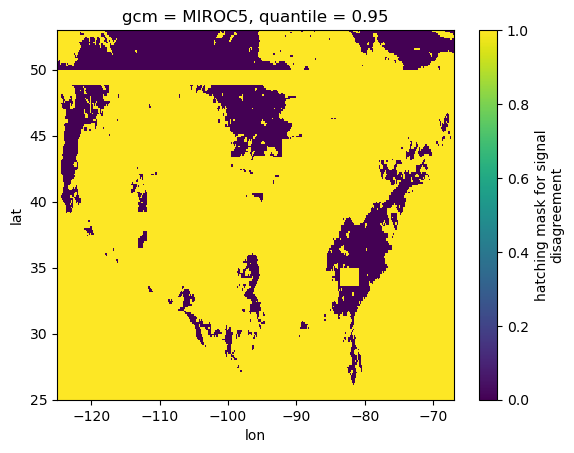

In [26]:
gcm = 'CanESM2'
gcm = 'MIROC5'
var = 
a.isel(member_id=0).sel(gcm=gcm)['disagreement'].plot(); plt.show()

In [28]:
a.isel(member_id=0)

<xarray.Dataset> Size: 23MB
Dimensions:               (gcm: 13, lat: 224, lon: 464)
Coordinates:
  * gcm                   (gcm) <U12 624B 'ACCESS-CM2' ... 'NorESM2-MM'
  * lat                   (lat) float32 896B 25.06 25.19 25.31 ... 52.81 52.94
  * lon                   (lon) float32 2kB -124.9 -124.8 ... -67.19 -67.06
    quantile              float64 8B ...
Data variables:
    agreement             (gcm, lat, lon) int8 1MB ...
    disagreement          (gcm, lat, lon) int8 1MB ...
    hatch_mask            (gcm, lat, lon) float32 5MB ...
    direction             (gcm, lat, lon) int8 1MB ...
    agree_positive        (gcm, lat, lon) int8 1MB ...
    agree_negative        (gcm, lat, lon) int8 1MB ...
    n_positive            (gcm, lat, lon) int16 3MB ...
    n_negative            (gcm, lat, lon) int16 3MB ...
    n_zero                (gcm, lat, lon) int16 3MB ...
    n_downscaling_models  (gcm, lat, lon) int16 3MB ...